In [8]:
import sys
import os

# Get the path of the notebook's parent folder (project root)
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)
print("Project root added to sys.path:", PROJECT_ROOT)

import sys
import os
import pandas as pd
from datetime import datetime, timedelta

# Add project root to sys.path so we can import our modules
PROJECT_ROOT = os.getcwd()  # adjust if notebook is in a subfolder
sys.path.insert(0, PROJECT_ROOT)

# Import the merge function
from src.ingestion.merge_data import merge_historical_data

# Your AQICN token
token = "361cf32474f50ec4ff9f3f677392739e1bfd8384"

# Fetch merged historical data
historical_df = merge_historical_data(city="karachi", token=token)

# Quick sanity check
print("Merged historical data loaded. Shape:", historical_df.shape)
display(historical_df.head())


[2026-02-02 23:34:26,324] [INFO] src.ingestion.merge_data - Fetching and merging historical data for karachi
[2026-02-02 23:34:26,329] [INFO] src.ingestion.station_resolver - Resolving AQICN station


Project root added to sys.path: c:\Users\NAWAB AHMAD\aqi-forecasting-mlops


[2026-02-02 23:34:29,602] [INFO] src.ingestion.station_resolver - Station resolved
[2026-02-02 23:34:29,607] [INFO] src.ingestion.openmeteo_historical_client - Fetching historical AQI from Open-Meteo
[2026-02-02 23:34:30,915] [INFO] src.ingestion.openmeteo_historical_client - Historical AQI normalized
[2026-02-02 23:34:31,533] [INFO] src.ingestion.openmeteo_weather_historical_client - Fetching historical weather from Open-Meteo
[2026-02-02 23:34:33,530] [INFO] src.ingestion.openmeteo_weather_historical_client - Historical weather normalized
[2026-02-02 23:34:33,837] [INFO] src.ingestion.merge_data - Merged historical data shape: (2904, 19)


Merged historical data loaded. Shape: (2904, 19)


,city_x,event_timestamp,source_x,ingested_at_x,pm25_pollutants,pm10_pollutants,no2_pollutants,so2_pollutants,o3_pollutants,co_pollutants,city_y,source_y,ingested_at_y,temperature_weather,humidity_weather,wind_speed_weather,wind_direction_weather,pressure_weather,precipitation_weather
0,karachi,2025-10-05 00:00:00+00:00,open-meteo,2026-02-02 18:34:30.909604+00:00,12.4,16.5,11.2,7.3,44.0,163.0,karachi,open-meteo-weather,2026-02-02 18:34:33.523626+00:00,26.5,94.0,5.7,257.0,1007.0,0.0
1,karachi,2025-10-05 01:00:00+00:00,open-meteo,2026-02-02 18:34:30.909604+00:00,13.8,18.3,13.6,9.5,46.0,198.0,karachi,open-meteo-weather,2026-02-02 18:34:33.523626+00:00,26.7,93.0,6.4,241.0,1007.2,0.1
2,karachi,2025-10-05 02:00:00+00:00,open-meteo,2026-02-02 18:34:30.909604+00:00,18.3,23.5,16.7,12.4,48.0,242.0,karachi,open-meteo-weather,2026-02-02 18:34:33.523626+00:00,27.0,90.0,7.2,242.0,1007.7,0.0
3,karachi,2025-10-05 03:00:00+00:00,open-meteo,2026-02-02 18:34:30.909604+00:00,18.2,25.0,17.7,14.7,54.0,271.0,karachi,open-meteo-weather,2026-02-02 18:34:33.523626+00:00,28.1,82.0,9.7,242.0,1008.2,0.1
4,karachi,2025-10-05 04:00:00+00:00,open-meteo,2026-02-02 18:34:30.909604+00:00,17.1,24.6,14.5,15.7,65.0,270.0,karachi,open-meteo-weather,2026-02-02 18:34:33.523626+00:00,29.1,76.0,10.7,243.0,1008.6,0.0


Inspect Missing Values and Data Types

In [9]:
# Step 1: Inspect missing values and data types
print("=== Data Types ===")
print(historical_df.dtypes)

print("\n=== Missing Values ===")
missing_counts = historical_df.isna().sum()
missing_percent = (missing_counts / len(historical_df)) * 100
missing_df = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent
}).sort_values(by="missing_percent", ascending=False)
display(missing_df)


=== Data Types ===
city_x                                 object
event_timestamp           datetime64[ns, UTC]
source_x                               object
ingested_at_x             datetime64[ns, UTC]
pm25_pollutants                       float64
pm10_pollutants                       float64
no2_pollutants                        float64
so2_pollutants                        float64
o3_pollutants                         float64
co_pollutants                         float64
city_y                                 object
source_y                               object
ingested_at_y             datetime64[ns, UTC]
temperature_weather                   float64
humidity_weather                      float64
wind_speed_weather                    float64
wind_direction_weather                float64
pressure_weather                      float64
precipitation_weather                 float64
dtype: object

=== Missing Values ===


,missing_count,missing_percent
city_x,0,0.0
city_y,0,0.0
pressure_weather,0,0.0
wind_direction_weather,0,0.0
wind_speed_weather,0,0.0
humidity_weather,0,0.0
temperature_weather,0,0.0
ingested_at_y,0,0.0
source_y,0,0.0
co_pollutants,0,0.0


Basic Cleaning / Column Selection

In [10]:
# Step 2: Select relevant columns for modeling
columns_to_keep = [
    "event_timestamp",
    "pm25_pollutants", "pm10_pollutants", "no2_pollutants",
    "so2_pollutants", "o3_pollutants", "co_pollutants",
    "temperature_weather", "humidity_weather", "wind_speed_weather",
    "wind_direction_weather", "pressure_weather", "precipitation_weather"
]

preprocessed_df = historical_df[columns_to_keep].copy()

# Optional: rename columns for clarity (snake_case standard)
preprocessed_df.rename(columns={
    "pm25_pollutants": "pm25",
    "pm10_pollutants": "pm10",
    "temperature_weather": "temperature",
    "humidity_weather": "humidity",
    "wind_speed_weather": "wind_speed",
    "wind_direction_weather": "wind_direction",
    "pressure_weather": "pressure",
    "precipitation_weather": "precipitation"
}, inplace=True)

# Quick check
print("Columns after basic cleaning:")
print(preprocessed_df.columns)
display(preprocessed_df.head())


Columns after basic cleaning:
Index(['event_timestamp', 'pm25', 'pm10', 'no2_pollutants', 'so2_pollutants',
       'o3_pollutants', 'co_pollutants', 'temperature', 'humidity',
       'wind_speed', 'wind_direction', 'pressure', 'precipitation'],
      dtype='object')


,event_timestamp,pm25,pm10,no2_pollutants,so2_pollutants,o3_pollutants,co_pollutants,temperature,humidity,wind_speed,wind_direction,pressure,precipitation
0,2025-10-05 00:00:00+00:00,12.4,16.5,11.2,7.3,44.0,163.0,26.5,94.0,5.7,257.0,1007.0,0.0
1,2025-10-05 01:00:00+00:00,13.8,18.3,13.6,9.5,46.0,198.0,26.7,93.0,6.4,241.0,1007.2,0.1
2,2025-10-05 02:00:00+00:00,18.3,23.5,16.7,12.4,48.0,242.0,27.0,90.0,7.2,242.0,1007.7,0.0
3,2025-10-05 03:00:00+00:00,18.2,25.0,17.7,14.7,54.0,271.0,28.1,82.0,9.7,242.0,1008.2,0.1
4,2025-10-05 04:00:00+00:00,17.1,24.6,14.5,15.7,65.0,270.0,29.1,76.0,10.7,243.0,1008.6,0.0


Visualize Outliers

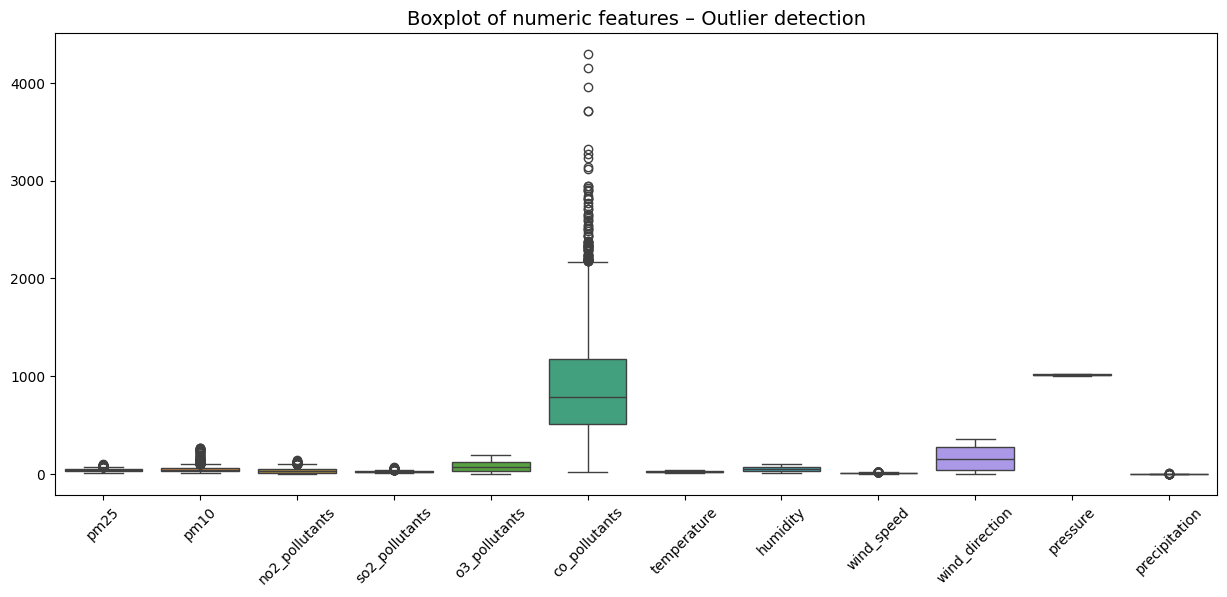

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_features = preprocessed_df.drop(columns=["event_timestamp"]).columns

plt.figure(figsize=(15, 6))
sns.boxplot(data=preprocessed_df[numeric_features])
plt.title("Boxplot of numeric features – Outlier detection", fontsize=14)
plt.xticks(rotation=45)
plt.show()
